# Baixar o Dataset e Extrair os Pontos

In [13]:
%%time
import os
import cv2
import numpy as np
import mediapipe as mp
import pandas as pd
import kagglehub
import joblib
import time
from sklearn.preprocessing import StandardScaler

print("1. A transferir o dataset do Kaggle...")
path = kagglehub.dataset_download("williansoliveira/libras")
caminho_train = os.path.join(path, "train")
caminho_test = os.path.join(path, "test")

print("2. A iniciar o MediaPipe...")
mp_maos = mp.solutions.hands
detector_maos = mp_maos.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=0.5)

def extrair_pontos(caminho_base):
    dados_X = []
    dados_y = []
    for letra in os.listdir(caminho_base):
        caminho_pasta_letra = os.path.join(caminho_base, letra)
        if not os.path.isdir(caminho_pasta_letra): continue
        
        for nome_arquivo in os.listdir(caminho_pasta_letra):
            caminho_imagem = os.path.join(caminho_pasta_letra, nome_arquivo)
            imagem = cv2.imread(caminho_imagem)
            if imagem is None: continue
            
            imagem_rgb = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)
            resultados = detector_maos.process(imagem_rgb)
            
            if resultados.multi_hand_landmarks:
                for landmarks in resultados.multi_hand_landmarks:
                    linha = []
                    pulso_x = landmarks.landmark[0].x
                    pulso_y = landmarks.landmark[0].y
                    pulso_z = landmarks.landmark[0].z
                    
                    for ponto in landmarks.landmark:
                        # Subtrai a posição do pulso de todos os outros pontos
                        linha.extend([
                            ponto.x - pulso_x, 
                            ponto.y - pulso_y, 
                            ponto.z - pulso_z
                        ])
                    dados_X.append(linha)
                    dados_y.append(letra)
    return np.array(dados_X), np.array(dados_y)

print("3. A extrair coordenadas do TREINO...")
inicio_treino = time.time()
X_train_bruto, y_train = extrair_pontos(caminho_train)
fim_treino = time.time()
print(f"   Concluído em {(fim_treino - inicio_treino):.2f} segundos.")

print("4. A extrair coordenadas do TESTE...")
inicio_teste = time.time()
X_test_bruto, y_test = extrair_pontos(caminho_test)
fim_teste = time.time()
print(f"   Concluído em {(fim_teste - inicio_teste):.2f} segundos.")

print("5. A padronizar a escala dos dados...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bruto)
X_test_scaled = scaler.transform(X_test_bruto)

print("6. A criar ficheiro de backup no disco...")
dados_ambiente = {
    'X_train': X_train_scaled,
    'X_test': X_test_scaled,
    'y_train': y_train,
    'y_test': y_test
}

joblib.dump(dados_ambiente, 'dados_ambiente.pkl')
joblib.dump(scaler, 'scaler_libras.pkl') 

print("✓ Sucesso! Divisão original do Kaggle respeitada.")
print(f"Tamanho do treino: {X_train_scaled.shape[0]} amostras.")
print(f"Tamanho do teste: {X_test_scaled.shape[0]} amostras.")

1. A transferir o dataset do Kaggle...
2. A iniciar o MediaPipe...
3. A extrair coordenadas do TREINO...


c:\Users\yujif\AppData\Local\Programs\Python\Python312\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


   Concluído em 1026.98 segundos.
4. A extrair coordenadas do TESTE...
   Concluído em 337.14 segundos.
5. A padronizar a escala dos dados...
6. A criar ficheiro de backup no disco...
✓ Sucesso! Divisão original do Kaggle respeitada.
Tamanho do treino: 34374 amostras.
Tamanho do teste: 11431 amostras.
CPU times: total: 22min 57s
Wall time: 22min 44s


# Treinamento da Rede Neural (MLP)

In [14]:
import time
import joblib
from sklearn.neural_network import MLPClassifier

print("A recuperar dados do backup...")
# Lê diretamente o arquivo PKL (esqueça o CSV!)
dados = joblib.load('dados_ambiente.pkl')
X_train_scaled, y_train = dados['X_train'], dados['y_train']

print("A iniciar Treinamento da IA 1: Rede Neural (MLP)...")
tempo_inicio = time.time()

modelo_mlp = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=1000, random_state=42)
modelo_mlp.fit(X_train_scaled, y_train)

tempo_fim = time.time()
print(f"✓ Treinamento concluído em {(tempo_fim - tempo_inicio):.2f} segundos.")

joblib.dump(modelo_mlp, 'modelo_mlp.pkl')
print("Modelo arquivado como 'modelo_mlp.pkl'.")

A recuperar dados do backup...
A iniciar Treinamento da IA 1: Rede Neural (MLP)...
✓ Treinamento concluído em 16.63 segundos.
Modelo arquivado como 'modelo_mlp.pkl'.


# Treinamento do Random Forest

In [15]:
import time
import joblib
from sklearn.ensemble import RandomForestClassifier

print("A recuperar dados do backup...")
dados = joblib.load('dados_ambiente.pkl')
X_train_scaled, y_train = dados['X_train'], dados['y_train']

print("A iniciar Treinamento da IA 2: Random Forest...")
tempo_inicio = time.time()

modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
modelo_rf.fit(X_train_scaled, y_train)

tempo_fim = time.time()
print(f"✓ Treinamento concluído em {(tempo_fim - tempo_inicio):.2f} segundos.")

joblib.dump(modelo_rf, 'modelo_rf.pkl')
print("Modelo arquivado como 'modelo_rf.pkl'.")

A recuperar dados do backup...
A iniciar Treinamento da IA 2: Random Forest...
✓ Treinamento concluído em 2.90 segundos.
Modelo arquivado como 'modelo_rf.pkl'.


# Avaliação, Comparação e Gráficos

A carregar o conjunto de testes e os modelos...

--- DESEMPENHO DA REDE NEURAL (MLP) ---
Acurácia Final: 99.61%
Loss Final (Perda): 0.0002

--- DESEMPENHO DO RANDOM FOREST ---
Acurácia Final: 99.21%
Nota: Random Forest não utiliza função de perda (Loss) por épocas.

O VENCEDOR É: Rede Neural MLP (Diferença de 0.39%)
Ficheiro definitivo 'modelo_libras_pontos_final.pkl' atualizado.

A gerar gráficos de análise...


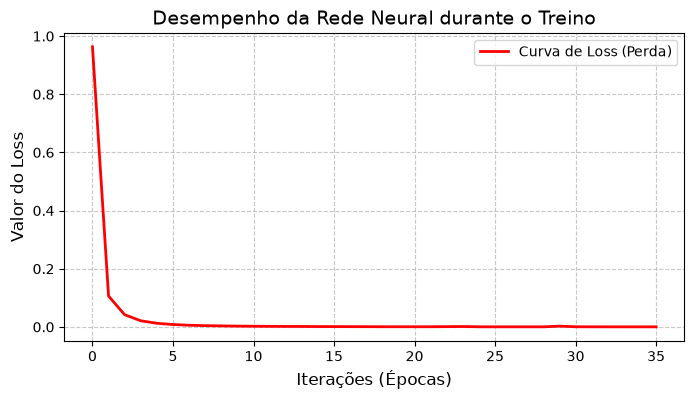

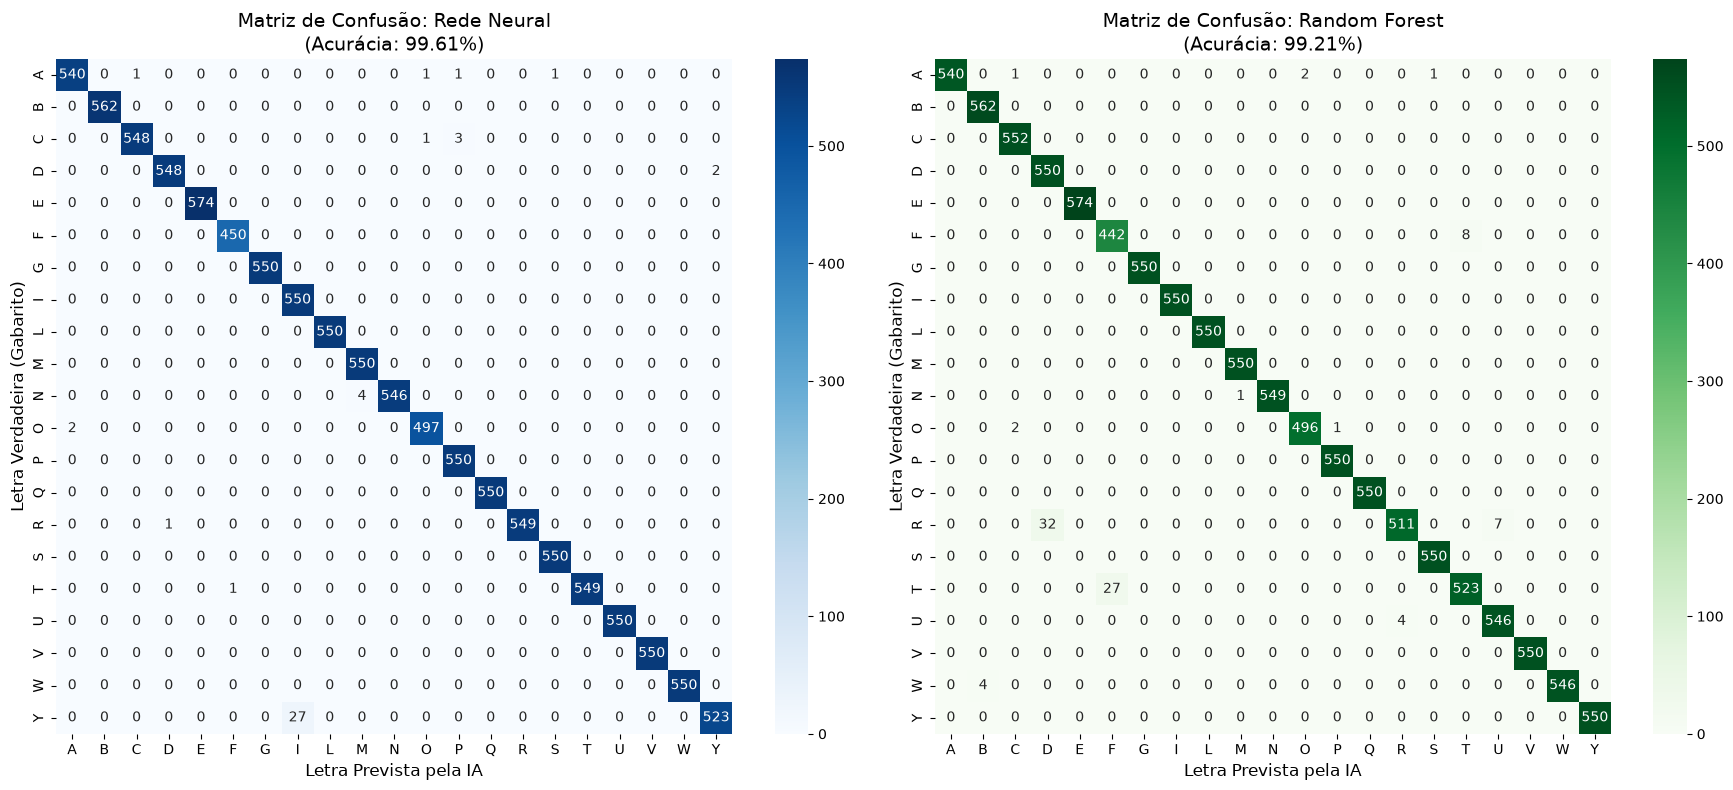


RELATÓRIO DE CLASSIFICAÇÃO - REDE NEURAL (MLP)
              precision    recall  f1-score   support

           A       1.00      0.99      0.99       544
           B       1.00      1.00      1.00       562
           C       1.00      0.99      1.00       552
           D       1.00      1.00      1.00       550
           E       1.00      1.00      1.00       574
           F       1.00      1.00      1.00       450
           G       1.00      1.00      1.00       550
           I       0.95      1.00      0.98       550
           L       1.00      1.00      1.00       550
           M       0.99      1.00      1.00       550
           N       1.00      0.99      1.00       550
           O       1.00      1.00      1.00       499
           P       0.99      1.00      1.00       550
           Q       1.00      1.00      1.00       550
           R       1.00      1.00      1.00       550
           S       1.00      1.00      1.00       550
           T       1.00      1.00

In [16]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("A carregar o conjunto de testes e os modelos...\n")
dados = joblib.load('dados_ambiente.pkl')
X_test_scaled, y_test = dados['X_test'], dados['y_test']

modelo_mlp = joblib.load('modelo_mlp.pkl')
modelo_rf = joblib.load('modelo_rf.pkl')

# PREVISÕES E MÉTRICAS BÁSICAS
# MLP
y_pred_mlp = modelo_mlp.predict(X_test_scaled)
acc_mlp = accuracy_score(y_test, y_pred_mlp)
loss_mlp = modelo_mlp.loss_ # A Perda final que o modelo alcançou

print("--- DESEMPENHO DA REDE NEURAL (MLP) ---")
print(f"Acurácia Final: {acc_mlp * 100:.2f}%")
print(f"Loss Final (Perda): {loss_mlp:.4f}\n")

# RANDOM FOREST
y_pred_rf = modelo_rf.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("--- DESEMPENHO DO RANDOM FOREST ---")
print(f"Acurácia Final: {acc_rf * 100:.2f}%")
print("Nota: Random Forest não utiliza função de perda (Loss) por épocas.\n")

# SELEÇÃO DO MODELO VENCEDOR
if acc_rf > acc_mlp:
    print(f"O VENCEDOR É: Random Forest (Diferença de {(acc_rf - acc_mlp)*100:.2f}%)")
    joblib.dump(modelo_rf, 'modelo_libras_pontos_final.pkl')
else:
    print(f"O VENCEDOR É: Rede Neural MLP (Diferença de {(acc_mlp - acc_rf)*100:.2f}%)")
    joblib.dump(modelo_mlp, 'modelo_libras_pontos_final.pkl')
print("Ficheiro definitivo 'modelo_libras_pontos_final.pkl' atualizado.\n")

# GRÁFICOS PARA O RELATÓRIO
print("A gerar gráficos de análise...")

# 1. Gráfico da Curva de Loss (Apenas Rede Neural)
plt.figure(figsize=(8, 4))
plt.plot(modelo_mlp.loss_curve_, label='Curva de Loss (Perda)', color='red', linewidth=2)
plt.title('Desempenho da Rede Neural durante o Treino', fontsize=14)
plt.xlabel('Iterações (Épocas)', fontsize=12)
plt.ylabel('Valor do Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 2. Matrizes de Confusão
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Matriz da MLP
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', 
            xticklabels=modelo_mlp.classes_, 
            yticklabels=modelo_mlp.classes_, ax=axes[0])
axes[0].set_title(f'Matriz de Confusão: Rede Neural\n(Acurácia: {acc_mlp*100:.2f}%)', fontsize=14)
axes[0].set_ylabel('Letra Verdadeira (Gabarito)', fontsize=12)
axes[0].set_xlabel('Letra Prevista pela IA', fontsize=12)

# Matriz do Random Forest (Direita)
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=modelo_rf.classes_, 
            yticklabels=modelo_rf.classes_, ax=axes[1])
axes[1].set_title(f'Matriz de Confusão: Random Forest\n(Acurácia: {acc_rf*100:.2f}%)', fontsize=14)
axes[1].set_ylabel('Letra Verdadeira (Gabarito)', fontsize=12)
axes[1].set_xlabel('Letra Prevista pela IA', fontsize=12)

plt.tight_layout()
plt.show()

# RELATÓRIOS ESTATÍSTICOS DETALHADOS
print("\n" + "="*60)
print("RELATÓRIO DE CLASSIFICAÇÃO - REDE NEURAL (MLP)")
print("="*60)
print(classification_report(y_test, y_pred_mlp))

print("\n" + "="*60)
print("RELATÓRIO DE CLASSIFICAÇÃO - RANDOM FOREST")
print("="*60)
print(classification_report(y_test, y_pred_rf))

# Resultados Visuais

Criando pasta de relatórios...
Gerando e salvando Matrizes de Confusão...
Gerando Mapa de Atenção (Feature Importance) do Random Forest...


C:\Users\yujif\AppData\Local\Temp\ipykernel_9736\3153034258.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancia_por_ponto, y=nomes_pontos, palette="magma")


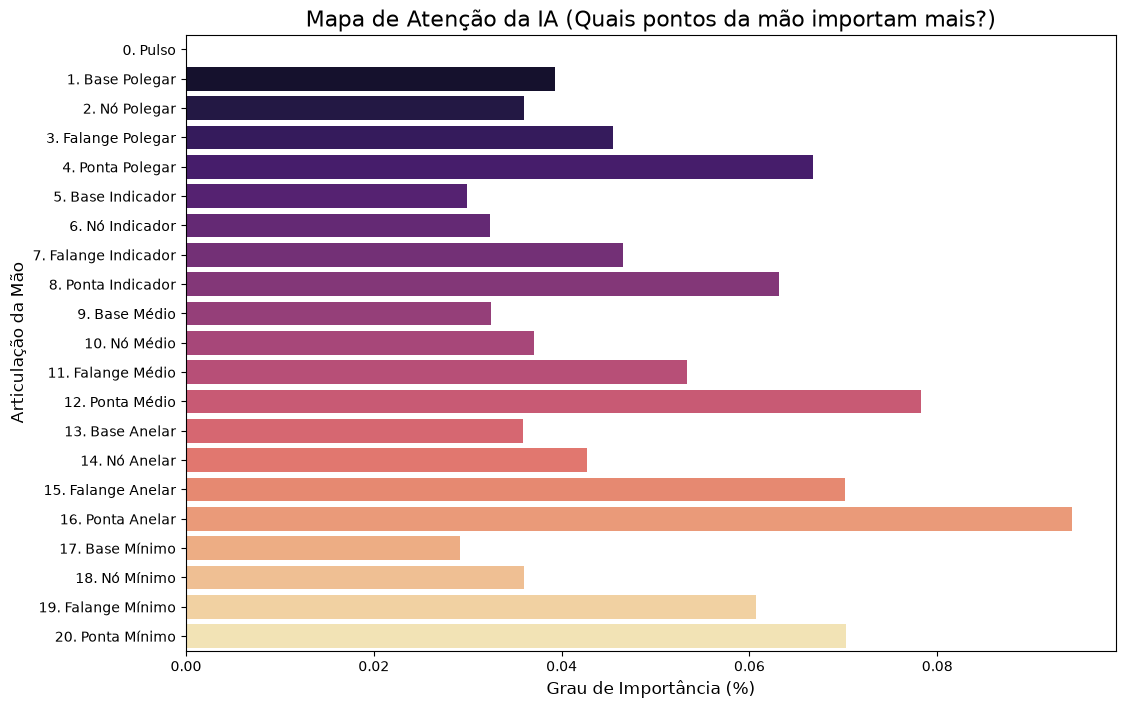

✓ Todos os gráficos foram salvos na pasta 'resultados_visuais' com alta resolução!


In [17]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Criando pasta de relatórios...")
pasta_resultados = "resultados_visuais"
os.makedirs(pasta_resultados, exist_ok=True)

dados = joblib.load('dados_ambiente.pkl')
X_test_scaled, y_test = dados['X_test'], dados['y_test']

modelo_mlp = joblib.load('modelo_mlp.pkl')
modelo_rf = joblib.load('modelo_rf.pkl')

print("Gerando e salvando Matrizes de Confusão...")

def salvar_matriz(modelo, nome_arquivo, cor):
    y_pred = modelo.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cor, 
                xticklabels=modelo.classes_, yticklabels=modelo.classes_)
    plt.title(f'Matriz de Confusão - {type(modelo).__name__}', fontsize=14)
    plt.ylabel('Letra Verdadeira')
    plt.xlabel('Letra Prevista')
    
    caminho = os.path.join(pasta_resultados, nome_arquivo)
    plt.savefig(caminho, bbox_inches='tight', dpi=300)
    plt.close() # Fecha para não poluir a tela

salvar_matriz(modelo_mlp, 'matriz_confusao_mlp.png', 'Blues')
salvar_matriz(modelo_rf, 'matriz_confusao_rf.png', 'Greens')

# O "MAPA DE CALOR" DO RANDOM FOREST
print("Gerando Mapa de Atenção (Feature Importance) do Random Forest...")

# O modelo tem 63 valores (21 pontos * 3 eixos). 
# Vamos somar a importância dos eixos X, Y, Z para cada um dos 21 pontos.
importancias_brutas = modelo_rf.feature_importances_
importancia_por_ponto = []

for i in range(21):
    # Soma a importância de X, Y e Z deste ponto específico
    importancia_ponto = importancias_brutas[i*3] + importancias_brutas[i*3+1] + importancias_brutas[i*3+2]
    importancia_por_ponto.append(importancia_ponto)

# Nomes dos 21 pontos mapeados pelo MediaPipe
nomes_pontos = [
    "0. Pulso", "1. Base Polegar", "2. Nó Polegar", "3. Falange Polegar", "4. Ponta Polegar",
    "5. Base Indicador", "6. Nó Indicador", "7. Falange Indicador", "8. Ponta Indicador",
    "9. Base Médio", "10. Nó Médio", "11. Falange Médio", "12. Ponta Médio",
    "13. Base Anelar", "14. Nó Anelar", "15. Falange Anelar", "16. Ponta Anelar",
    "17. Base Mínimo", "18. Nó Mínimo", "19. Falange Mínimo", "20. Ponta Mínimo"
]

# Cria um gráfico de barras horizontais (Mapa de calor estatístico)
plt.figure(figsize=(12, 8))
sns.barplot(x=importancia_por_ponto, y=nomes_pontos, palette="magma")
plt.title('Mapa de Atenção da IA (Quais pontos da mão importam mais?)', fontsize=16)
plt.xlabel('Grau de Importância (%)', fontsize=12)
plt.ylabel('Articulação da Mão', fontsize=12)

caminho_importancia = os.path.join(pasta_resultados, 'mapa_atencao_rf.png')
plt.savefig(caminho_importancia, bbox_inches='tight', dpi=300)
plt.show()

print(f"✓ Todos os gráficos foram salvos na pasta '{pasta_resultados}' com alta resolução!")